# DMEPOS by Referring Provider & Service EDA

In this workbook we perform exploritory data analysis on the cleaned, combined DMEPOS by referring provider and service dataset (`DMEPOS_rfrhpr_clean.csv`). This workbook produces the key artifact `DMEPOS_rfrhpr_clean_labeled.csv` which is a critical input for further data modeling and machine learning.

## Import and label data

In [3]:
import pandas as pd
# read-in clean rfrhpr data
df = pd.read_csv('/dsa/groups/casestudycf25/team02/DMEPOS_rfrhpr_clean.csv',dtype={'Rfrg_Prvdr_State_FIPS':str,'Rfrg_Prvdr_Zip5':str}) # ensure Rfrg_Prvdr_State_FIPS & Rfrg_Prvdr_Zip5 are imported as str
df.head()

,Rfrg_NPI,Rfrg_Prvdr_Last_Name_Org,Rfrg_Prvdr_First_Name,Rfrg_Prvdr_MI,Rfrg_Prvdr_Crdntls,Rfrg_Prvdr_Ent_Cd,Rfrg_Prvdr_St1,Rfrg_Prvdr_St2,Rfrg_Prvdr_City,Rfrg_Prvdr_State_Abrvtn,...,Suplr_Rentl_Ind,Tot_Suplrs,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Avg_Suplr_Sbmtd_Chrg,Avg_Suplr_Mdcr_Alowd_Amt,Avg_Suplr_Mdcr_Pymt_Amt,Avg_Suplr_Mdcr_Stdzd_Amt,Year
0,1003000126,Enkeshafi,Ardalan,NaN,md,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Y,5,5.0,16,16,46.336250,20.097500,14.857500,15.280000,2021
1,1003000126,Enkeshafi,Ardalan,NaN,md,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Y,6,5.0,19,19,360.770000,98.223158,72.843684,79.753158,2021
2,1003000126,Enkeshafi,Ardalan,NaN,md,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Y,1,5.0,11,11,92.000000,39.230000,31.385455,33.552727,2021
3,1003000126,Enkeshafi,Ardalan,NaN,md,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Y,1,5.0,11,11,20.000000,10.210909,8.169091,8.456364,2021
4,1003000480,Rothchild,Kevin,B,md,I,12605 E 16th Ave,NaN,Aurora,CO,...,Y,4,5.0,11,13,272.003846,80.513846,64.407692,84.701538,2021


In [4]:
# read-in clean leie data
labs = pd.read_csv('/dsa/groups/casestudycf25/team02/leie_with_valid_npi_clean.csv',dtype={'npi':int}) # make sure npi numbers are read as int
labs.head()

,general,specialty,npi,excltype,excldate,num_exclusions_alltime,num_exclusion_types_alltime,list_exclusion_types_alltime,num_addresses_alltime,new_id,fraud_flag,excl_1128a1,excl_1128a2,excl_1128a3,excl_1128b5,excl_1128b6,excl_1128b7,excl_brch cia
0,IND- LIC HC SERV PRO,DENTIST,1861529091,1128a3,2024-03-20,1.0,1.0,['1128a3'],1.0,AAMIR-WAHAB-nan-1979-11-16,1,0,0,1,0,0,0,0
1,IND- LIC HC SERV PRO,CHIROPRACTIC,1366544512,1128b7,2021-08-16,1.0,1.0,['1128b7'],1.0,AARON-OXENRIDER-nan-1976-06-07,1,0,0,0,0,0,1,0
2,IND- LIC HC SERV PRO,HEALTH CARE AIDE,1376214585,1128a1,2025-01-20,1.0,1.0,['1128a1'],1.0,AARON-WALTON-nan-1971-11-19,1,1,0,0,0,0,0,0
3,BUS OWNER/EXEC,COUNSELING CENTER,1326353459,1128a1,2022-03-20,1.0,1.0,['1128a1'],1.0,AARON-WILLIAMS-nan-1962-10-20,1,1,0,0,0,0,0,0
4,BUS OWNER/EXEC,ASSISTED LIVING FACI,1578130340,1128a1,2025-07-20,1.0,1.0,['1128a1'],1.0,ABDOULIE-LOWE-nan-1975-12-27,1,1,0,0,0,0,0,0


In [5]:
# return excldate first four digits as int
# print(labs['excldate'][0][:4])

labs['EXCLDATE'] = labs.excldate.apply(lambda x: int(x[:4]))

# reduce labs to strictly necessary cols
labs = labs[['npi','fraud_flag','EXCLDATE']]

labs.head()

,npi,fraud_flag,EXCLDATE
0,1861529091,1,2024
1,1366544512,1,2021
2,1376214585,1,2025
3,1326353459,1,2022
4,1578130340,1,2025


In [6]:
# merge labs w/ df on npi, retain all NPIs in df
df = pd.merge(labs, df, how='right', left_on='npi', right_on='Rfrg_NPI')
df.head()

,npi,fraud_flag,EXCLDATE,Rfrg_NPI,Rfrg_Prvdr_Last_Name_Org,Rfrg_Prvdr_First_Name,Rfrg_Prvdr_MI,Rfrg_Prvdr_Crdntls,Rfrg_Prvdr_Ent_Cd,Rfrg_Prvdr_St1,...,Suplr_Rentl_Ind,Tot_Suplrs,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Avg_Suplr_Sbmtd_Chrg,Avg_Suplr_Mdcr_Alowd_Amt,Avg_Suplr_Mdcr_Pymt_Amt,Avg_Suplr_Mdcr_Stdzd_Amt,Year
0,1.265697e+09,1.0,2024.0,1265697478,Balger,Abigail,NaN,md,I,805 E Geneva Dr,...,N,1,25.0,25,25,1100.000000,802.673200,623.734400,617.563600,2021
1,1.265697e+09,1.0,2024.0,1265697478,Balger,Abigail,NaN,md,I,805 E Geneva Dr,...,N,1,24.0,24,45,800.000000,575.352000,429.419333,388.558889,2021
2,1.922096e+09,1.0,2024.0,1922096221,Alperovich,Alexander,NaN,md,I,1340 Union University Dr,...,N,4,5.0,11,11,391.454545,127.299091,101.008182,88.409091,2021
3,1.922096e+09,1.0,2024.0,1922096221,Alperovich,Alexander,NaN,md,I,1340 Union University Dr,...,N,5,14.0,16,16,75.225000,26.028125,20.823750,18.594375,2021
4,1.922096e+09,1.0,2024.0,1922096221,Alperovich,Alexander,NaN,md,I,1340 Union University Dr,...,N,5,12.0,16,16,80.843750,24.173750,18.241875,14.060000,2021


In [7]:
# impute missing values
df['npi'] = df['npi'].fillna(df['Rfrg_NPI'].astype(int))
df['fraud_flag'] = df['fraud_flag'].fillna(0)
df['EXCLDATE'] = df['EXCLDATE'].fillna(0)
df['npi'] = df.npi.astype(int)

df.head()

,npi,fraud_flag,EXCLDATE,Rfrg_NPI,Rfrg_Prvdr_Last_Name_Org,Rfrg_Prvdr_First_Name,Rfrg_Prvdr_MI,Rfrg_Prvdr_Crdntls,Rfrg_Prvdr_Ent_Cd,Rfrg_Prvdr_St1,...,Suplr_Rentl_Ind,Tot_Suplrs,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Avg_Suplr_Sbmtd_Chrg,Avg_Suplr_Mdcr_Alowd_Amt,Avg_Suplr_Mdcr_Pymt_Amt,Avg_Suplr_Mdcr_Stdzd_Amt,Year
0,1265697478,1.0,2024.0,1265697478,Balger,Abigail,NaN,md,I,805 E Geneva Dr,...,N,1,25.0,25,25,1100.000000,802.673200,623.734400,617.563600,2021
1,1265697478,1.0,2024.0,1265697478,Balger,Abigail,NaN,md,I,805 E Geneva Dr,...,N,1,24.0,24,45,800.000000,575.352000,429.419333,388.558889,2021
2,1922096221,1.0,2024.0,1922096221,Alperovich,Alexander,NaN,md,I,1340 Union University Dr,...,N,4,5.0,11,11,391.454545,127.299091,101.008182,88.409091,2021
3,1922096221,1.0,2024.0,1922096221,Alperovich,Alexander,NaN,md,I,1340 Union University Dr,...,N,5,14.0,16,16,75.225000,26.028125,20.823750,18.594375,2021
4,1922096221,1.0,2024.0,1922096221,Alperovich,Alexander,NaN,md,I,1340 Union University Dr,...,N,5,12.0,16,16,80.843750,24.173750,18.241875,14.060000,2021


In [8]:
def make_labels(fraud_flag, start_exc, data_yr):
    if start_exc >= data_yr: # some fraudulent providers have claims during the year the were added to the LEIE
        return fraud_flag
    else:
        return 0

df['target'] = df[['fraud_flag','EXCLDATE','Year']].apply(lambda x: make_labels(*x), axis=1)
df.head()

,npi,fraud_flag,EXCLDATE,Rfrg_NPI,Rfrg_Prvdr_Last_Name_Org,Rfrg_Prvdr_First_Name,Rfrg_Prvdr_MI,Rfrg_Prvdr_Crdntls,Rfrg_Prvdr_Ent_Cd,Rfrg_Prvdr_St1,...,Tot_Suplrs,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Avg_Suplr_Sbmtd_Chrg,Avg_Suplr_Mdcr_Alowd_Amt,Avg_Suplr_Mdcr_Pymt_Amt,Avg_Suplr_Mdcr_Stdzd_Amt,Year,target
0,1265697478,1.0,2024.0,1265697478,Balger,Abigail,NaN,md,I,805 E Geneva Dr,...,1,25.0,25,25,1100.000000,802.673200,623.734400,617.563600,2021,1.0
1,1265697478,1.0,2024.0,1265697478,Balger,Abigail,NaN,md,I,805 E Geneva Dr,...,1,24.0,24,45,800.000000,575.352000,429.419333,388.558889,2021,1.0
2,1922096221,1.0,2024.0,1922096221,Alperovich,Alexander,NaN,md,I,1340 Union University Dr,...,4,5.0,11,11,391.454545,127.299091,101.008182,88.409091,2021,1.0
3,1922096221,1.0,2024.0,1922096221,Alperovich,Alexander,NaN,md,I,1340 Union University Dr,...,5,14.0,16,16,75.225000,26.028125,20.823750,18.594375,2021,1.0
4,1922096221,1.0,2024.0,1922096221,Alperovich,Alexander,NaN,md,I,1340 Union University Dr,...,5,12.0,16,16,80.843750,24.173750,18.241875,14.060000,2021,1.0


### Write-out labeled dataset

In [9]:
# convert target to int and drop unnecessary cols
df = df.drop(['fraud_flag','EXCLDATE','Rfrg_NPI'], axis=1)
df['target'] = df.target.astype(int)

# save as csv for future reference
df.to_csv('/dsa/groups/casestudycf25/team02/DMEPOS_rfrhpr_clean_labeled.csv', index=False)

df.head()

,npi,Rfrg_Prvdr_Last_Name_Org,Rfrg_Prvdr_First_Name,Rfrg_Prvdr_MI,Rfrg_Prvdr_Crdntls,Rfrg_Prvdr_Ent_Cd,Rfrg_Prvdr_St1,Rfrg_Prvdr_St2,Rfrg_Prvdr_City,Rfrg_Prvdr_State_Abrvtn,...,Tot_Suplrs,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Avg_Suplr_Sbmtd_Chrg,Avg_Suplr_Mdcr_Alowd_Amt,Avg_Suplr_Mdcr_Pymt_Amt,Avg_Suplr_Mdcr_Stdzd_Amt,Year,target
0,1265697478,Balger,Abigail,NaN,md,I,805 E Geneva Dr,NaN,Dewitt,MI,...,1,25.0,25,25,1100.000000,802.673200,623.734400,617.563600,2021,1
1,1265697478,Balger,Abigail,NaN,md,I,805 E Geneva Dr,NaN,Dewitt,MI,...,1,24.0,24,45,800.000000,575.352000,429.419333,388.558889,2021,1
2,1922096221,Alperovich,Alexander,NaN,md,I,1340 Union University Dr,NaN,Jackson,TN,...,4,5.0,11,11,391.454545,127.299091,101.008182,88.409091,2021,1
3,1922096221,Alperovich,Alexander,NaN,md,I,1340 Union University Dr,NaN,Jackson,TN,...,5,14.0,16,16,75.225000,26.028125,20.823750,18.594375,2021,1
4,1922096221,Alperovich,Alexander,NaN,md,I,1340 Union University Dr,NaN,Jackson,TN,...,5,12.0,16,16,80.843750,24.173750,18.241875,14.060000,2021,1


## Import labeled file and perform EDA

In [1]:
import pandas as pd
# read-in the labeled data to verify successful save
df = pd.read_csv('/dsa/groups/casestudycf25/team02/DMEPOS_rfrhpr_clean_labeled.csv',dtype={'Rfrg_Prvdr_State_FIPS':str,'Rfrg_Prvdr_Zip5':str})
df.head()

,npi,Rfrg_Prvdr_Last_Name_Org,Rfrg_Prvdr_First_Name,Rfrg_Prvdr_MI,Rfrg_Prvdr_Crdntls,Rfrg_Prvdr_Ent_Cd,Rfrg_Prvdr_St1,Rfrg_Prvdr_St2,Rfrg_Prvdr_City,Rfrg_Prvdr_State_Abrvtn,...,Tot_Suplrs,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Avg_Suplr_Sbmtd_Chrg,Avg_Suplr_Mdcr_Alowd_Amt,Avg_Suplr_Mdcr_Pymt_Amt,Avg_Suplr_Mdcr_Stdzd_Amt,Year,target
0,1265697478,Balger,Abigail,NaN,md,I,805 E Geneva Dr,NaN,Dewitt,MI,...,1,25.0,25,25,1100.000000,802.673200,623.734400,617.563600,2021,1
1,1265697478,Balger,Abigail,NaN,md,I,805 E Geneva Dr,NaN,Dewitt,MI,...,1,24.0,24,45,800.000000,575.352000,429.419333,388.558889,2021,1
2,1922096221,Alperovich,Alexander,NaN,md,I,1340 Union University Dr,NaN,Jackson,TN,...,4,5.0,11,11,391.454545,127.299091,101.008182,88.409091,2021,1
3,1922096221,Alperovich,Alexander,NaN,md,I,1340 Union University Dr,NaN,Jackson,TN,...,5,14.0,16,16,75.225000,26.028125,20.823750,18.594375,2021,1
4,1922096221,Alperovich,Alexander,NaN,md,I,1340 Union University Dr,NaN,Jackson,TN,...,5,12.0,16,16,80.843750,24.173750,18.241875,14.060000,2021,1


In [2]:
# inspect the overall dataset descriptive stats
pd.options.display.float_format = '{:,.2f}'.format 
pd.set_option('display.max_rows', None)

df_stats = df.drop(['npi','Rfrg_Prvdr_RUCA','Year','target'], axis=1).describe().T
df_stats

,count,mean,std,min,25%,50%,75%,max
Tot_Suplrs,"4,413,118.00",4.35,5.18,1.00,1.00,3.00,5.00,208.00
Tot_Suplr_Benes,"4,413,118.00",14.57,38.78,5.00,5.00,5.00,12.00,"8,172.00"
Tot_Suplr_Clms,"4,413,118.00",42.45,94.67,11.00,13.00,19.00,35.00,"13,871.00"
Tot_Suplr_Srvcs,"4,413,118.00","1,263.49","18,244.36",11.00,16.00,34.00,139.00,"5,402,250.00"
Avg_Suplr_Sbmtd_Chrg,"4,413,118.00",209.19,554.40,0.00,19.25,69.69,190.00,"77,612.10"
Avg_Suplr_Mdcr_Alowd_Amt,"4,413,118.00",75.43,263.02,0.00,8.02,23.05,62.38,"27,701.77"
Avg_Suplr_Mdcr_Pymt_Amt,"4,413,118.00",57.67,206.43,0.00,5.31,17.11,46.31,"21,718.19"
Avg_Suplr_Mdcr_Stdzd_Amt,"4,413,118.00",59.00,206.77,0.00,5.52,17.49,50.29,"21,496.42"


In [3]:
# create seperate fraud and non-fraud dfs
df_nonfraud = df[df.target==0]
df_fraud = df[df.target==1]

In [4]:
# inspect non-fraud descriptive stats
df_nonfraud_stats = df_nonfraud.drop(['npi','Rfrg_Prvdr_RUCA','Year','target'], axis=1).describe().T
df_nonfraud_stats

,count,mean,std,min,25%,50%,75%,max
Tot_Suplrs,"4,411,705.00",4.35,5.18,1.00,1.00,3.00,5.00,208.00
Tot_Suplr_Benes,"4,411,705.00",14.57,38.65,5.00,5.00,5.00,12.00,"8,172.00"
Tot_Suplr_Clms,"4,411,705.00",42.45,94.60,11.00,13.00,19.00,35.00,"13,871.00"
Tot_Suplr_Srvcs,"4,411,705.00","1,263.68","18,247.21",11.00,16.00,34.00,139.00,"5,402,250.00"
Avg_Suplr_Sbmtd_Chrg,"4,411,705.00",209.18,554.39,0.00,19.25,69.69,190.00,"77,612.10"
Avg_Suplr_Mdcr_Alowd_Amt,"4,411,705.00",75.42,263.01,0.00,8.02,23.05,62.38,"27,701.77"
Avg_Suplr_Mdcr_Pymt_Amt,"4,411,705.00",57.66,206.43,0.00,5.31,17.11,46.31,"21,718.19"
Avg_Suplr_Mdcr_Stdzd_Amt,"4,411,705.00",58.99,206.77,0.00,5.53,17.49,50.29,"21,496.42"


In [5]:
# inspect fraud descriptive stats
df_fraud_stats = df_fraud.drop(['npi','Rfrg_Prvdr_RUCA','Year','target'], axis=1).describe().T
df_fraud_stats

,count,mean,std,min,25%,50%,75%,max
Tot_Suplrs,"1,413.00",4.49,6.23,1.00,1.00,3.00,5.00,73.00
Tot_Suplr_Benes,"1,413.00",35.30,178.68,5.00,5.00,5.00,13.00,"2,987.00"
Tot_Suplr_Clms,"1,413.00",61.22,217.11,11.00,13.00,20.00,37.00,"3,881.00"
Tot_Suplr_Srvcs,"1,413.00",683.93,"2,681.03",11.00,17.00,39.00,219.00,"63,000.00"
Avg_Suplr_Sbmtd_Chrg,"1,413.00",240.57,573.35,0.13,12.74,57.95,187.00,"5,457.34"
Avg_Suplr_Mdcr_Alowd_Amt,"1,413.00",104.84,269.25,0.03,5.23,20.34,66.64,"3,026.97"
Avg_Suplr_Mdcr_Pymt_Amt,"1,413.00",80.41,210.06,0.02,3.99,14.91,47.42,"2,359.51"
Avg_Suplr_Mdcr_Stdzd_Amt,"1,413.00",81.48,214.98,0.02,4.24,15.56,50.29,"2,696.02"


In [6]:
# calculated squared differences of means normalized by total population std_dev 
# offers rudementary feature importance ranking
Nrmd_Sqrd_Class_Mean_Diff = ((df_nonfraud_stats['mean'] - df_fraud_stats['mean'])**2)/df_stats['std'] # calculation
df_stats['Nrmd_Sqrd_Class_Mean_Diff'] = Nrmd_Sqrd_Class_Mean_Diff
df_stats.sort_values(by='Nrmd_Sqrd_Class_Mean_Diff', ascending=False)

,count,mean,std,min,25%,50%,75%,max,Nrmd_Sqrd_Class_Mean_Diff
Tot_Suplr_Srvcs,"4,413,118.00","1,263.49","18,244.36",11.00,16.00,34.00,139.00,"5,402,250.00",18.42
Tot_Suplr_Benes,"4,413,118.00",14.57,38.78,5.00,5.00,5.00,12.00,"8,172.00",11.09
Tot_Suplr_Clms,"4,413,118.00",42.45,94.67,11.00,13.00,19.00,35.00,"13,871.00",3.72
Avg_Suplr_Mdcr_Alowd_Amt,"4,413,118.00",75.43,263.02,0.00,8.02,23.05,62.38,"27,701.77",3.29
Avg_Suplr_Mdcr_Pymt_Amt,"4,413,118.00",57.67,206.43,0.00,5.31,17.11,46.31,"21,718.19",2.51
Avg_Suplr_Mdcr_Stdzd_Amt,"4,413,118.00",59.00,206.77,0.00,5.52,17.49,50.29,"21,496.42",2.45
Avg_Suplr_Sbmtd_Chrg,"4,413,118.00",209.19,554.40,0.00,19.25,69.69,190.00,"77,612.10",1.78
Tot_Suplrs,"4,413,118.00",4.35,5.18,1.00,1.00,3.00,5.00,208.00,0.00


After normalizing each feature by its standard deviation in the population, the differences in means between the fraud and non-fraud classes are most pronounced for the Total Supplier Services and Total Supplier Beneficiaries features where average is greater for the non-fraud class. However, this may be explained by the presence of outliers in the non-fraud class which the fraud class lacks as further analysis will show. I try another metric which is not sensitive to outliers which is the absolute difference of medians of the classes divided by the population's inter-quartile range (Abs_Nrmd_Class_Median_Diff). 

In [7]:
df_stats['IQR'] = df_stats['75%'] - df_stats['25%']
nrmd_median_diff = abs(df_fraud_stats['50%'] - df_nonfraud_stats['50%'])/df_stats['IQR']
df_stats['Abs_Nrmd_Class_Median_Diff'] = nrmd_median_diff
df_stats.sort_values(by='Abs_Nrmd_Class_Median_Diff', ascending=False)

,count,mean,std,min,25%,50%,75%,max,Nrmd_Sqrd_Class_Mean_Diff,IQR,Abs_Nrmd_Class_Median_Diff
Avg_Suplr_Sbmtd_Chrg,"4,413,118.00",209.19,554.40,0.00,19.25,69.69,190.00,"77,612.10",1.78,170.75,0.07
Avg_Suplr_Mdcr_Pymt_Amt,"4,413,118.00",57.67,206.43,0.00,5.31,17.11,46.31,"21,718.19",2.51,41.01,0.05
Avg_Suplr_Mdcr_Alowd_Amt,"4,413,118.00",75.43,263.02,0.00,8.02,23.05,62.38,"27,701.77",3.29,54.36,0.05
Tot_Suplr_Clms,"4,413,118.00",42.45,94.67,11.00,13.00,19.00,35.00,"13,871.00",3.72,22.00,0.05
Avg_Suplr_Mdcr_Stdzd_Amt,"4,413,118.00",59.00,206.77,0.00,5.52,17.49,50.29,"21,496.42",2.45,44.76,0.04
Tot_Suplr_Srvcs,"4,413,118.00","1,263.49","18,244.36",11.00,16.00,34.00,139.00,"5,402,250.00",18.42,123.00,0.04
Tot_Suplrs,"4,413,118.00",4.35,5.18,1.00,1.00,3.00,5.00,208.00,0.00,4.00,0.00
Tot_Suplr_Benes,"4,413,118.00",14.57,38.78,5.00,5.00,5.00,12.00,"8,172.00",11.09,7.00,0.00


By the normalized absolute difference in medians between classes, the typical amounts of Total Supliers and Total Supplier Beneficiaries for fraudulent and legitimate providers are virtually indistiguishable between fraudulant and legitimate providers respectively. Instead, we find slightly lower Average Supplier Submitted Charges, Average Supplier Medicare Payment Amounts, Average Supplier Medicare Allowed Amounts, and Average Supplier Medicare Standardized Amounts for fraudulent providers as well as slightly higher Total Supplier Claims. We may speculate that the submission of lower-value claims with a greater frequency is indicative of fraud.

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
x = df['Avg_Suplr_Mdcr_Alowd_Amt']
y = df['Avg_Suplr_Sbmtd_Chrg']


# Create the scatter plot
plt.scatter(x, y)

# Add labels and title (optional but recommended)
plt.xlabel("Avg Allowed Amount")
plt.ylabel("Avg Submitted Charge")
plt.title("Submitted Charge vs Allowed Amount")


# plt.savefig("allowed_amts.png")
# Display the plot
plt.show()



<Figure size 640x480 with 1 Axes>

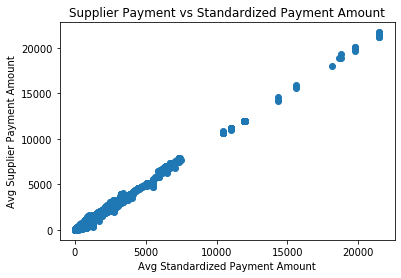

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
x = df['Avg_Suplr_Mdcr_Stdzd_Amt']
y = df['Avg_Suplr_Mdcr_Pymt_Amt']


# Create the scatter plot
plt.scatter(x, y)

# Add labels and title (optional but recommended)
plt.xlabel("Avg Standardized Payment Amount")
plt.ylabel("Avg Supplier Payment Amount")
plt.title("Supplier Payment vs Standardized Payment Amount")

# plt.savefig("pmt_amts.png")

# Display the plot
plt.show()


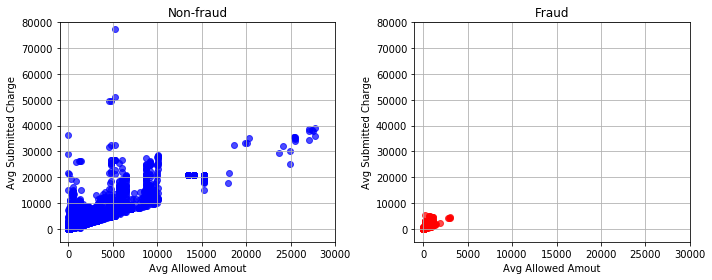

In [10]:
import matplotlib.pyplot as plt
import numpy as np

x_0 = df['Avg_Suplr_Mdcr_Alowd_Amt'][df.target==0]
y_0 = df['Avg_Suplr_Sbmtd_Chrg'][df.target==0]

x_1 = df['Avg_Suplr_Mdcr_Alowd_Amt'][df.target==1]
y_1 = df['Avg_Suplr_Sbmtd_Chrg'][df.target==1]


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# Add labels and title (optional but recommended)
plt.xlabel("Avg Standardized Payment Amount")
plt.ylabel("Avg Supplier Payment Amount")
plt.title("Supplier Payment vs Standardized Payment Amount")

# Plot on the first subplot (left)
axes[0].scatter(x_0, y_0, color='blue', alpha=0.7)
axes[0].set_xlim(-1000,30000)
axes[0].set_ylim(-5000,80000)
axes[0].set_title('Non-fraud')
axes[0].set_xlabel('Avg Allowed Amout')
axes[0].set_ylabel('Avg Submitted Charge')
axes[0].grid(True)

# Plot on the second subplot (right)
axes[1].scatter(x_1, y_1, color='red', alpha=0.7)
axes[1].set_xlim(-1000,30000)
axes[1].set_ylim(-5000,80000)
axes[1].set_title('Fraud')
axes[1].set_xlabel('Avg Allowed Amout')
axes[1].set_ylabel('Avg Submitted Charge')
axes[1].grid(True)

# Adjust layout to prevent titles/labels from overlapping
plt.tight_layout()

# save the figure
# plt.savefig("submitted_v_allowed_by_class.png")

# Display the plots
plt.show()

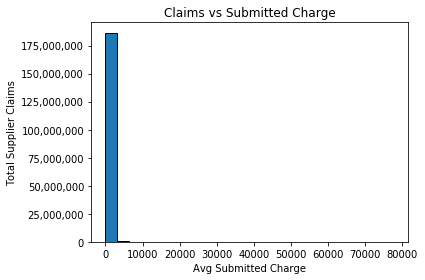

In [25]:
# look at Total Supplier Cliams and a fn of Avg Submitted Charge
# this tells us whether it is normal for providers to submit greater numbers of lower-value claims
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Sample data
x = df['Avg_Suplr_Sbmtd_Chrg']
y = df['Tot_Suplr_Clms']


# Create the scatter plot
# plt.scatter(x, y)

# Create histogram
plt.hist(x, weights=y, bins=25, edgecolor='black')

# Get the current axes (gca = get current axes)
ax = plt.gca()

# format tickmark labels
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Add labels and title (optional but recommended)
plt.xlabel("Avg Submitted Charge")
plt.ylabel("Total Supplier Claims")
plt.title("Claims vs Submitted Charge")

plt.tight_layout()

# plt.savefig("tot_claims_v_submitted.png")
# Display the plot
plt.show()

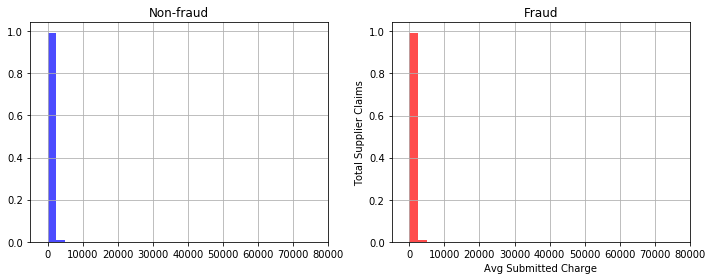

In [24]:
# providers tend to submit more claims for lower-value charges overall
# are the patterns noticebly distinct between classes
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

x_0 = df['Avg_Suplr_Sbmtd_Chrg'][df.target==0]
y_0_raw = df['Tot_Suplr_Clms'][df.target==0]

x_1 = df['Avg_Suplr_Sbmtd_Chrg'][df.target==1]
y_1_raw = df['Tot_Suplr_Clms'][df.target==1]

y_0 = y_0_raw/y_0_raw.sum()
y_1 = y_1_raw/y_1_raw.sum()

bins = np.arange(0, 80000, 2500)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# Add labels and title (optional but recommended)
plt.xlabel("Avg Submitted Charge")
plt.ylabel("Total Supplier Claims")
plt.title("Claims vs Submitted Charges")

# Plot on the first subplot (left)
axes[0].hist(x_0, weights=y_0, bins=bins, color='blue', alpha=0.7)
axes[0].set_xlim(-5000,80000)
# axes[0].set_ylim(0,190000000)
axes[0].set_title('Non-fraud')
# axes[0].set_xlabel('Avg Allowed Amout')
# axes[0].set_ylabel('Avg Submitted Charge')
axes[0].grid(True)

# Plot on the second subplot (right)
axes[1].hist(x_1, weights=y_1, bins=bins, color='red', alpha=0.7)
axes[1].set_xlim(-5000,80000)
# axes[1].set_ylim(0,190000000)
axes[1].set_title('Fraud')
# axes[1].set_xlabel('Avg Allowed Amout')
# axes[1].set_ylabel('Avg Submitted Charge')
axes[1].grid(True)

# Adjust layout to prevent titles/labels from overlapping
plt.tight_layout()

# plt.savefig("tot_claims_v_submitted_by_class.png")

# Display the plots
plt.show()